## Multicellular Factor Analysis across molecular, morphological, and spatial feature types

---
**NOTE**  
This is an advanced user notebook. Familiarity with MOFA-based multicellular factor analysis and spatial or imaging-based single-cell data is assumed.

---

Patient maps generated with mc-ASTRA can integrate multiple tissue descriptors into a shared latent space. In previous tutorials, we focused mainly on expression-derived or pathway-derived multicellular programs. Imaging-based spatial proteomics provides additional layers of information: marker intensity, cell morphology, and spatial organization.

In this tutorial, we extend the mc-ASTRA workflow to combine three feature types from the same colorectal cancer tissue samples:

- marker-intensity profiles for each cell type, summarizing metabolic and lineage-associated proteins
- morphology profiles, summarizing cell size and shape features across cell types
- spatial co-localization profiles, summarizing neighborhood enrichment between cell types

A multicellular factor model is then fitted across all views, allowing latent factors to capture coordinated variation across molecular, morphological, and spatial tissue structure.

---

### Application to colorectal cancer spatial proteomics

We apply this workflow to MIBI spatial proteomics data from colorectal cancer (CRC) tissue microarrays, with samples annotated by pathological tumor stage (`pT`). The data include per-cell protein marker intensities, spatial coordinates, morphology measurements, and consensus cell-type annotations.

This vignette is a simplified workflow based on [Vulliard et al. (arXiv, 2025)](https://arxiv.org/abs/2510.05083). Here, we use mc-ASTRA to ask whether tumor-stage progression is reflected in coordinated changes across metabolic marker activity, immune and stromal cell morphology, and spatial cell-type organization.

---

### Learning goals

- Build a multiview patient representation from imaging-derived single-cell features.
- Combine cell-type marker profiles, morphology descriptors, and spatial co-localization features in one factor model.
- Test latent factors for association with pathological tumor stage.
- Interpret a stage-associated factor by separating molecular, morphological, and spatial loadings.

## Imports and data loading

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)

import mc_astra as mca
import numpy as np
import pandas as pd
import anndata as ad
import mudata as md
import decoupler as dc
import scanpy as sc
import mofaflex as mf
import matplotlib.pyplot as plt
import seaborn as sns

/home/loan/Documents/Tests/mc-astra/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/loan/Documents/Tests/mc-astra/.venv/lib/python3.13/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/loan/Documents/Tests/mc-astra/.venv/lib/python3.13/site-packages


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



The example data are available from Zenodo: https://zenodo.org/records/18504904

We start from a per-cell `AnnData` table containing marker intensities, morphology features, spatial coordinates, sample identifiers, and consensus cell-type annotations. A separate clinical table provides the pathological tumor-stage annotation for each tissue microarray core.

The downstream workflow changes the unit of analysis from individual cells to tissue samples (`fov`) and represents each sample through several coordinated views.

In [ ]:
# Starting from cell table with annotations
# Get files and explanations here: https://zenodo.org/records/18504904
features = ad.read_h5ad("/home/loan/Downloads/adata_consensus_cell_types.h5ad")
annotations = pd.read_csv("/home/loan/Downloads/summary_clinical_data_modified.csv")

In [3]:
# For reference, per-cell info in .obs include metabolic markers, spatial coordinates,
# morphological features, sample idea (fov) and cell type annotations.
features.obs.columns

Index(['CA9', 'nuclei', 'CD98', 'CytC', 'MSH2', 'MCT1', 'PDL1', 'PD1', 'ASCT2',
       'LDH', 'STING1', 'DCN', 'GS', 'GLS', 'ATP5A', 'CS', 'PKM2', 'GLUT1',
       'MSH6', 'ARG1', 'CPT1A', 'Vimentin', 'Ki67', 'membrane', 'centroid-0',
       'centroid-1', 'eccentricity', 'perimeter', 'convex_area', 'area',
       'axis_major_length', 'axis_minor_length', 'label', 'fov',
       'annotation_t', 'annotation_scyan', 'consensus',
       'annotation_consensus'],
      dtype='str')

## Preprocessing

We first attach the pathological tumor-stage annotation (`pT_group`) to each cell by matching cells to their tissue microarray core. We then simplify the consensus annotations into a curated set of cell types that are well represented across samples.

This step defines the analysis scope: downstream views are built only from annotated tumor-stage samples and selected cell populations, making the molecular, morphological, and spatial summaries comparable across tissue samples.

In [4]:
# Transfer the pT group of each TMA core to the cells of the matching FOV
pT_by_core = annotations.set_index("TMA Localisation")["pT group"]
fov = features.obs["fov"].astype(str)
features.obs["pT_group"] = pd.Categorical(fov.map(pT_by_core))

In [5]:
types_of_interest = dict(
    Fibroblast = ["CAF"],
    Macrophage = ["CD163_Macrophage", "CD68_Macrophage"],
    CD4_lymphocyte = ["CD4_Tcell", "T_reg_cell"],
    Epithelial_cell = ["Cancer_cell"],
    Endothelial_cell = ["Endothelial_cell"],
    Monocyte = ["Monocyte"],
    Cytotoxic_lymphocyte = ["NK_cell", "CD8_Tcell"],
)

In [6]:
# Map the cell types of interest to the cell type column in the features object
features.obs["celltype"] = features.obs["annotation_consensus"].map(lambda x: next((key for key, values in types_of_interest.items() if x in values ), "Other"))

In [7]:
# Extract features to summarize
ft_per_cell = [
       'CD98', 'CytC', 'MCT1', 'ASCT2',
       'LDH', 'GS', 'GLS', 'ATP5A', 'CS', 
       'ARG1', 'GLUT1', 'PKM2', 'CPT1A'
       ]
# Processed together with the markers, but moved to a dedicated view further down
morpho_ft_per_cell = ['eccentricity', 'perimeter', 'convex_area', 'area',
       'axis_major_length', 'axis_minor_length',
       ]

metadata = mca.up.extract_metadata_from_obs(obs=features.obs, groupby="fov", sort=False)
adata = ad.AnnData(
    X = features.obs.loc[:,ft_per_cell + morpho_ft_per_cell],
    obs = features.obs.loc[:,["fov", "celltype", "pT_group"]],
    obsm = {"spatial": features.obs.loc[:,["centroid-0", "centroid-1"]].values},
    var = pd.DataFrame(index = ft_per_cell + morpho_ft_per_cell)
)

In [8]:
# Keep only annotated samples and selected cell types
adata = adata[adata.obs['pT_group'].isin(["pT1", "pT2", "pT3", "pT4"])]
adata = adata[adata.obs['celltype'].isin(list(types_of_interest.keys()))]
# Z-score features
sc.pp.scale(adata)

## Compute and arrange feature types

Next, we convert the per-cell table into sample-level views. For each tissue sample (`fov`) and cell type, marker intensities and morphology measurements are summarized using pseudobulk-style aggregation.

We then construct three complementary inputs for the model:

- one marker-intensity view per cell type
- one spatial view describing cell-type neighborhood enrichment
- one morphology view describing cell-type-specific size and shape features

Together, these views represent each CRC sample through molecular activity, cellular morphology, and tissue organization.

In [ ]:
# Pseudo bulk: summarize each feature by its mean and standard deviation, per FOV and cell type
pdata = dc.pp.pseudobulk(
    adata,
    sample_col="fov",
    groups_col="celltype",
    mode={"mean": lambda x: np.mean(x, axis=0)},
    skip_checks=True,  # Z-scored intensities, not raw counts
)

# Samples are the observations shared across views
pdata.obs = pdata.obs.set_index("fov", drop=False)
pdata.obs.index.name = None

# Feature names of each group, means and standard deviations
metabolic_vars = ft_per_cell
morpho_vars = morpho_ft_per_cell
pdata

AnnData object with n_obs × n_vars = 3150 × 19
    obs: 'fov', 'celltype', 'pT_group', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    layers: 'mean', 'psbulk_props'

In [10]:
# Split by cell type, leaving the morphological features out
anndata_dict = mca.up.split_anndata_by_celltype(pdata=pdata[:,metabolic_vars], grouping="celltype")
anndata_dict = {k: v for k, v in anndata_dict.items() if v.n_obs > 0}
mca.up.filter_anndata_by_ncells(anndata_dict, min_cells=10)
mca.up.utils.append_view_to_var(anndata_dict)

In [11]:
spatial_interaction_adata = mca.up.get_nhood_enrichment_feats(
    adata,
    sample_key="fov",
    cluster_key="celltype",
    diagonal = True, # To not be biased by compositions
    n_perms=1000,
    metadata=metadata
)

# Don't forget to add the view name to the variables for compatibility
mca.up.utils.append_view_to_var({"Spatial":spatial_interaction_adata})

anndata_dict["Spatial"] = spatial_interaction_adata

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:00<00:00, 10225.82/s]

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        



100%|██████████| 1000/1000 [00:00<00:00, 10815.50/s]

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


...


100%|██████████| 1000/1000 [00:00<00:00, 12262.29/s]


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:00<00:00, 11567.43/s]


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:00<00:00, 14048.02/s]


In [12]:
# Add a morphological view to the anndata_dict
# Format Morpho:celltype_feature

# Same minimum number of cells as for the cell type views
morpho_pdata = pdata[pdata.obs["psbulk_cells"] >= 10, morpho_vars]

# Reshape into one observation per FOV and one feature per celltype/morphology pair
morpho_wide = morpho_pdata.to_df()
morpho_wide.index = pd.MultiIndex.from_frame(morpho_pdata.obs[["fov", "celltype"]])
morpho_wide = morpho_wide.unstack("celltype")
morpho_wide.columns = [f"{celltype}_{ft}" for ft, celltype in morpho_wide.columns]

morpho_adata = ad.AnnData(
    X = morpho_wide.to_numpy(dtype=float, copy=True),
    obs = pd.DataFrame(index=morpho_wide.index).join(metadata, how="left"),
    var = pd.DataFrame(index=morpho_wide.columns),
)
morpho_adata.obs.index.name = None

# Don't forget to add the view name to the variables for compatibility
mca.up.utils.append_view_to_var({"Morpho": morpho_adata})

anndata_dict["Morpho"] = morpho_adata

## Fit the multicellular factor model

We now combine all views in a `MuData` object and fit a MOFA-FLEX model. The model learns latent factors that explain coordinated variation across marker-intensity, morphology, and spatial co-localization views.

In this setting, each factor represents a sample-level axis of tissue variation. A factor may be driven mostly by one feature type, or by a coordinated combination of molecular, morphological, and spatial changes.

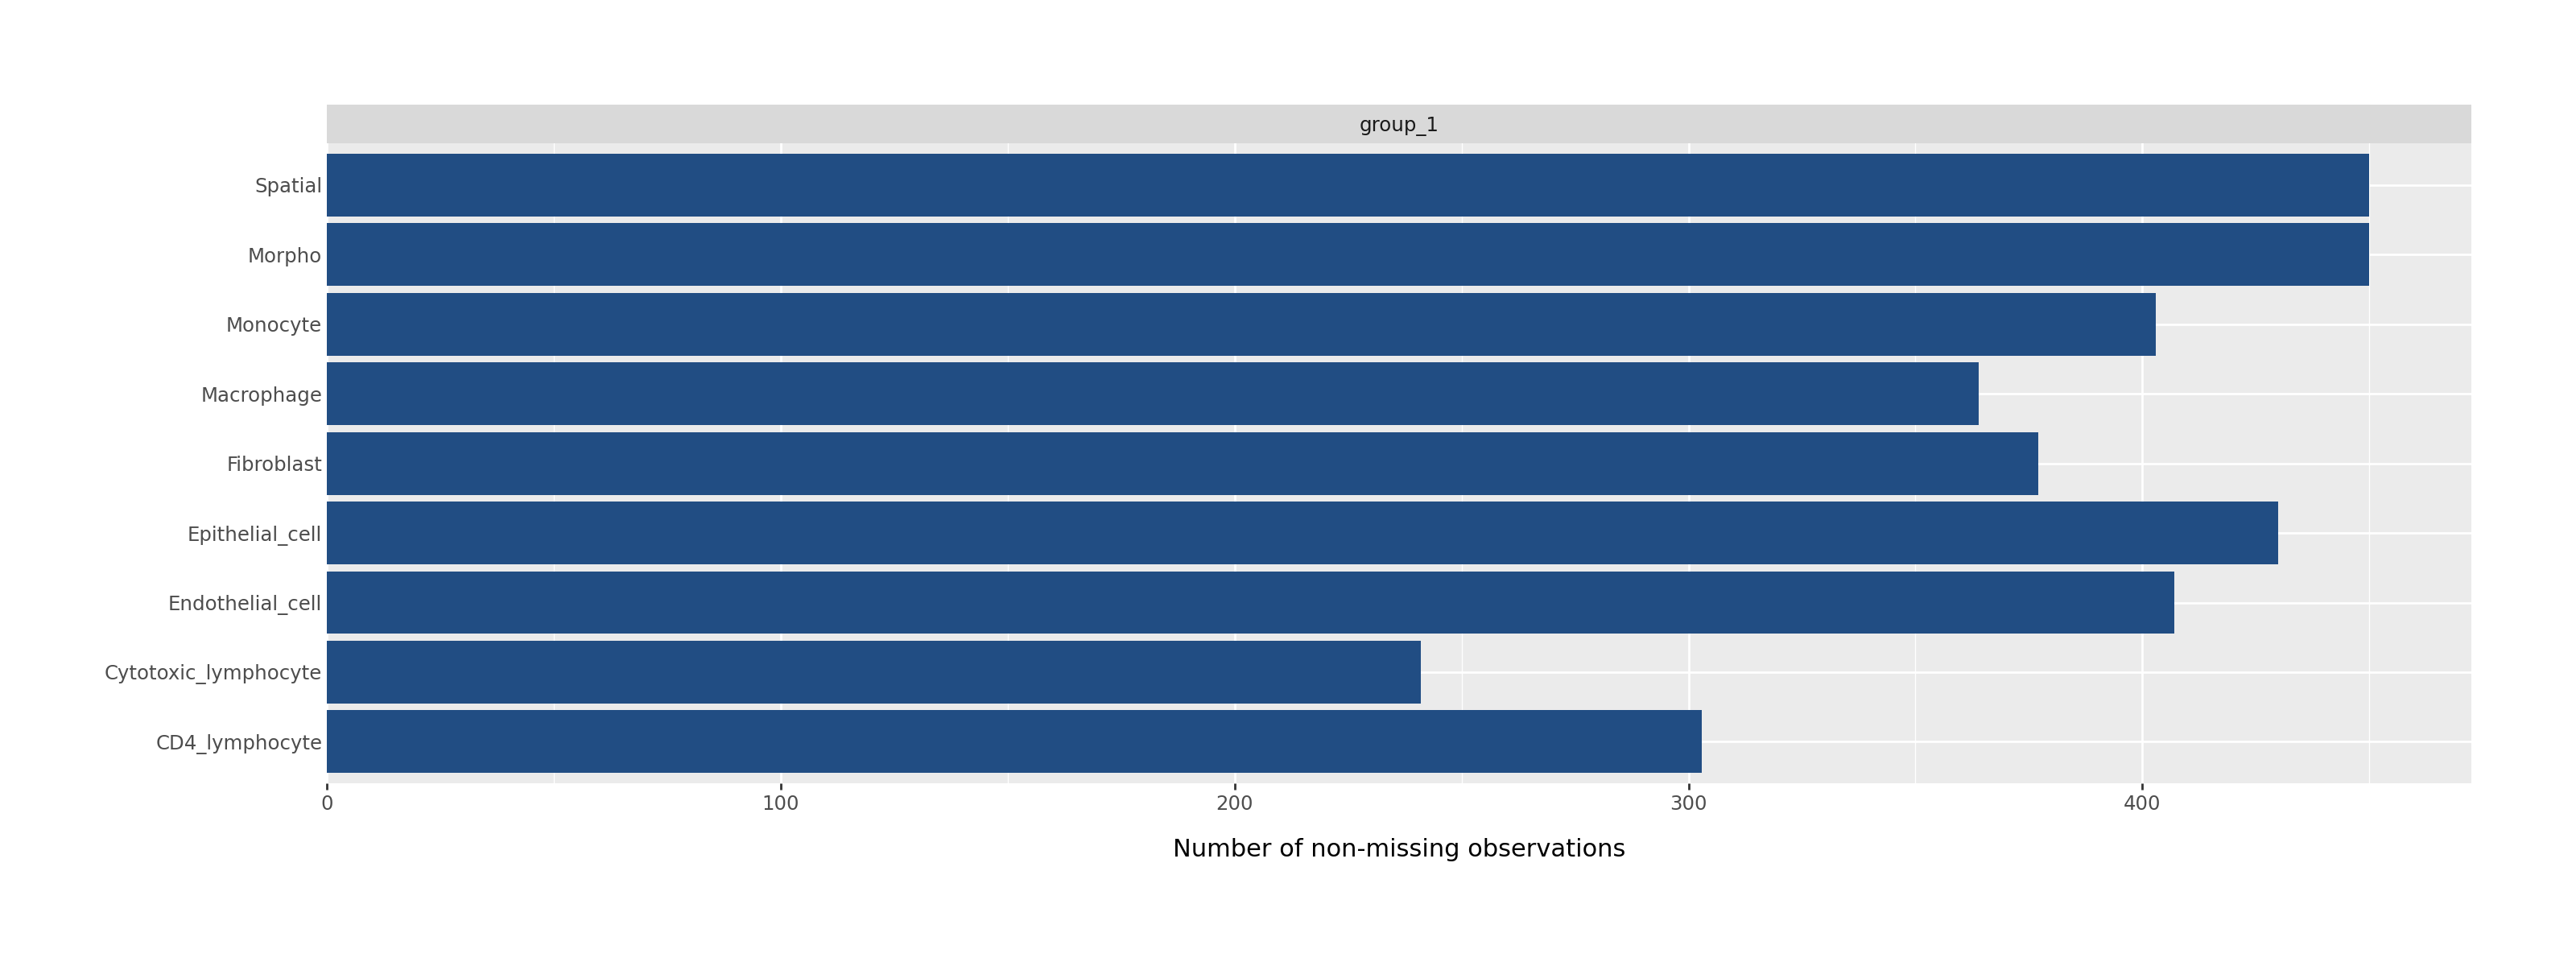

2026-08-31 19:31:23 | [INFO] Initializing factors using 'pca' method...
 80%|████████  | 8026/10000 [10:19<02:32, 12.95epoch/s, Loss=113]


In [13]:
mdata = md.MuData(anndata_dict)
# Fitting model
model = mf.terms.MofaFlex(
    n_factors=5,
    factor_prior="Normal",
    weight_prior="Horseshoe",
    nonnegative_factors=False,
    nonnegative_weights=False,
    init_factors="pca",
)

model.fit(mdata, seed=0,
            # max_epochs=5000,
            early_stopper_patience=1000,
            save_path=False, lr=0.001, likelihoods="Normal")

In [14]:
# Total variance explained by all factors together (reconstruction performance)
model.get_r2(type="total").sort_values(by="R2", ascending=False)

,group,view,R2
0,group_1,CD4_lymphocyte,0.715053
1,group_1,Cytotoxic_lymphocyte,0.703507
6,group_1,Monocyte,0.688967
5,group_1,Macrophage,0.664597
4,group_1,Fibroblast,0.637510
2,group_1,Endothelial_cell,0.628097
8,group_1,Morpho,0.537218
3,group_1,Epithelial_cell,0.429442
7,group_1,Spatial,0.336087


## Test factor associations with tumor stage

After fitting the model, we convert the latent representation into an `AnnData` object for downstream analysis. We then test whether any learned factors are associated with pathological tumor stage (`pT_group`).

This step links unsupervised patient-map structure back to a known clinical variable, helping identify which latent axes capture tumor-stage-related remodeling.

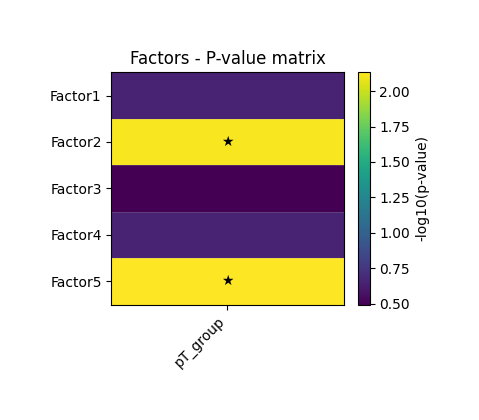

In [26]:
amodel = mca.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mca.down.get_pval_matrix(amodel,["pT_group"])
mca.pl.plot_pval_tiles(all_assocs, title="Factors - P-value matrix",star_threshold=0.1)
plt.show()

In [27]:
assocs = mca.down.get_associations(amodel, 
                           test_variable = "pT_group",
                           test_type="categorical",
                           random_effect = None)
assocs.sort_values("adj_p_value")

,feature,statistic,p_value,adj_p_value
4,Factor5,5.232989,0.001472,0.007362
1,Factor2,4.699536,0.003050,0.007626
3,Factor4,1.638351,0.179753,0.224692
0,Factor1,1.815720,0.143489,0.224692
2,Factor3,1.169515,0.320927,0.320927


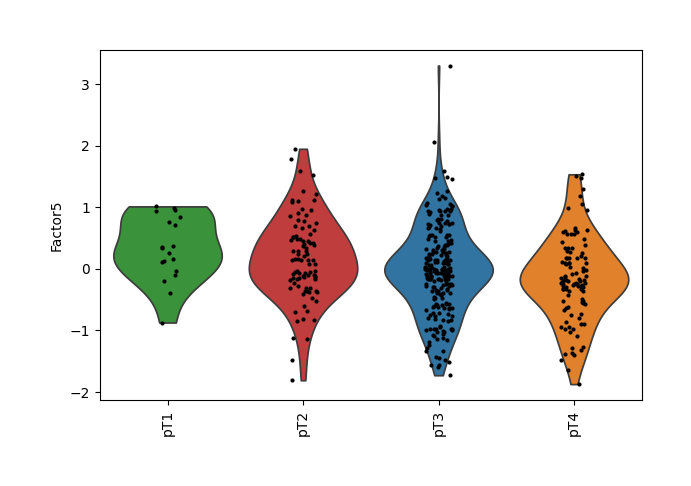

In [30]:
# Keep the factor that separates the tumor stages best
sel_factor = assocs.sort_values("adj_p_value")["feature"].iloc[0]

sc.pl.violin(amodel, 
             sel_factor, 
             groupby="pT_group", 
             rotation=90,
             size = 3,
             dodge=False)

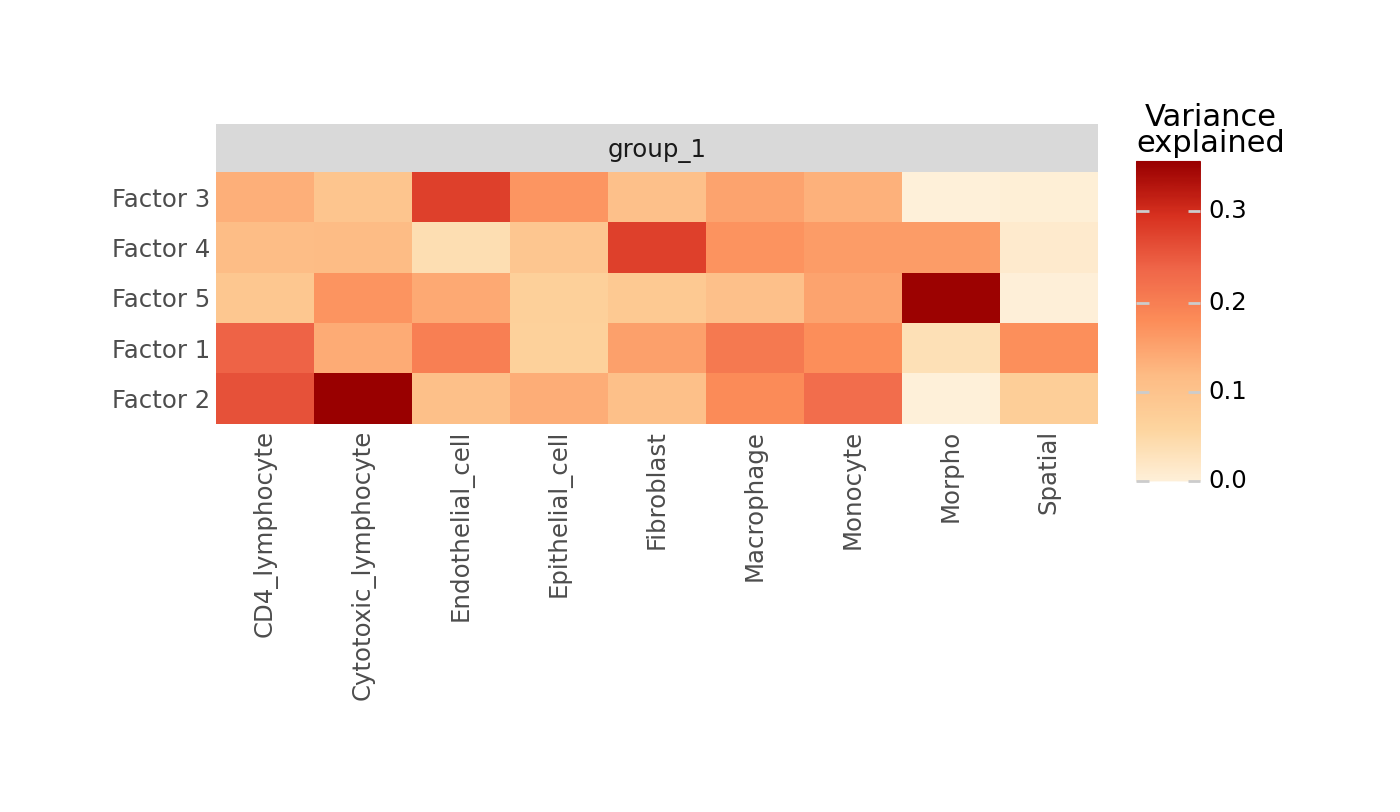

In [31]:
mf.pl.variance_explained(model, figsize=(6,3))

In [32]:
# Variance explained per view by the factors associated with the tumor stage
total_var = mca.down.calc_total_variance(amodel, assocs, pval_thrs=0.05)
pd.DataFrame(total_var).T

feature,group_1
CD4_lymphocyte,0.352674
Cytotoxic_lymphocyte,0.526839
Endothelial_cell,0.250853
Epithelial_cell,0.205356
Fibroblast,0.194474
Macrophage,0.289201
Monocyte,0.375602
Morpho,0.354193
Spatial,0.074553


## Characterize the factor capturing tissue remodeling

Once a tumor-stage-associated factor is identified, we inspect its loadings to understand which features drive the signal.

We separate the interpretation into two parts:

- tissue-structure loadings, including spatial co-localization and morphology features
- marker-intensity loadings, describing metabolic and lineage-associated protein signals across cell types

This makes it possible to distinguish whether the factor is mainly molecular, morphological, spatial, or a coordinated combination of these feature types.

In [33]:
feature_loadings = pd.DataFrame(amodel.varm["gene_loadings"], columns=amodel.uns['gene_loadings_columns'])
feature_loadings.index = amodel.var.index.to_list()
# Make a dictionary of marker loadings and of tissue structure loadings
feature_loadings = mca.down.split_by_view(feature_loadings)
structure_loadings = {view: feature_loadings[view] for view in ["Spatial", "Morpho"]}
feature_loadings = {k: v for k, v in feature_loadings.items() if k not in structure_loadings}

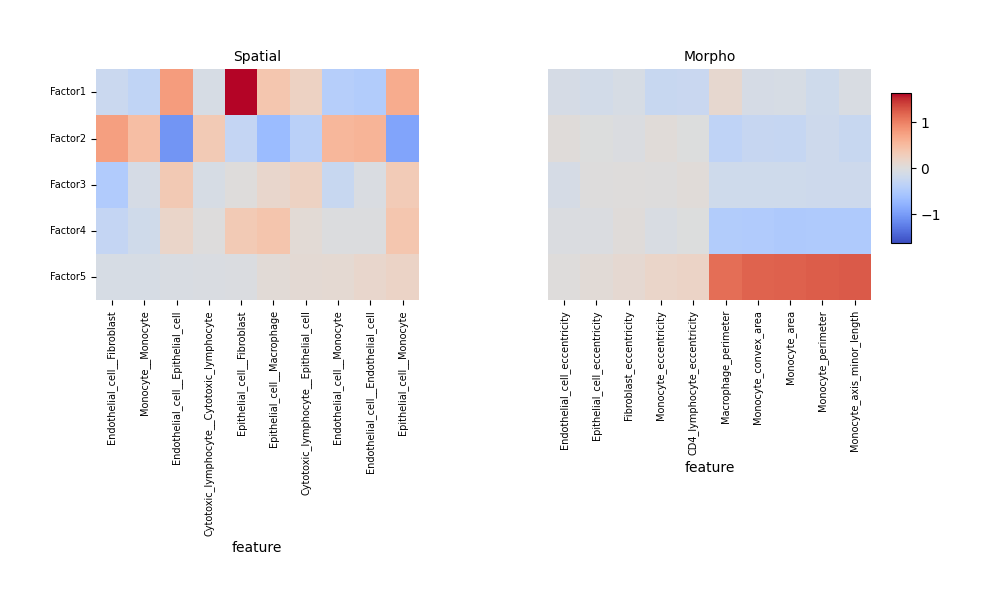

In [35]:
# Pick the most negative and positive loadings of each tissue structure view
top_loadings = []
for loadings in structure_loadings.values():
    view_loadings = loadings.loc[sel_factor, :].sort_values()
    top_loadings += view_loadings.head(5).index.tolist() + view_loadings.tail(5).index.tolist()

mca.pl.plot_features_per_view(df_dict=structure_loadings, 
                               features=top_loadings, 
                               figsize=(10, 3))

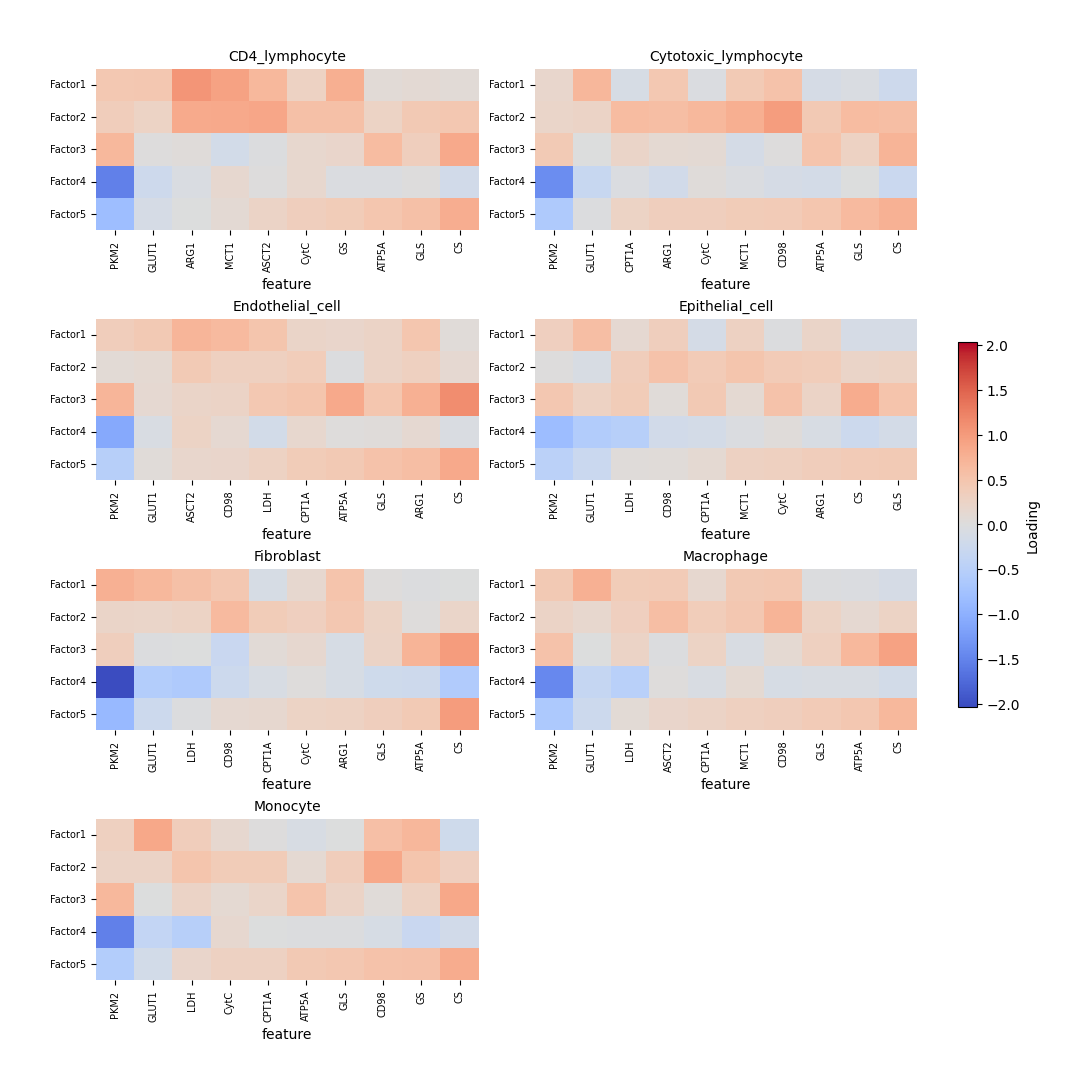

In [36]:
# Pick the 5 most negative and positive marker loadings of each cell type
top_loadings = {}
for view, loadings in feature_loadings.items():
    view_loadings = loadings.loc[sel_factor, :].sort_values()
    top_loadings[view] = view_loadings.head(5).index.tolist() + view_loadings.tail(5).index.tolist()

# The marker views share their feature names, so each cell type gets its own heatmap
n_cols = 2
n_rows = -(-len(top_loadings) // n_cols)
vmax = max(feature_loadings[view][fts].abs().to_numpy().max() for view, fts in top_loadings.items())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.5 * n_rows), layout="constrained")
for ax, (view, fts) in zip(axes.flat, top_loadings.items()):
    sns.heatmap(feature_loadings[view][fts], cmap="coolwarm", center=0, vmin=-vmax, vmax=vmax, cbar=False, ax=ax)
    ax.set_title(view, fontsize=10)
    ax.tick_params(axis="x", labelsize=7, rotation=90)
    ax.tick_params(axis="y", labelsize=7, rotation=0)

# Hide the unused panels of the last row
for ax in list(axes.flat)[len(top_loadings):]:
    ax.set_axis_off()

fig.colorbar(axes.flat[0].collections[0], ax=axes, shrink=0.4, label="Loading")
plt.show()

## Summary

In this vignette, we used mc-ASTRA to build a multimodal patient map from CRC spatial proteomics data. Instead of modeling marker intensities alone, we incorporated three complementary feature types: cell-type-specific marker profiles, morphology descriptors, and spatial co-localization features.

The fitted model identifies a factor associated with pathological tumor stage. In this example, the selected factor decreases with stage and is strongly influenced by morphology: monocytes and macrophages show larger morphology-related features, while marker loadings suggest lower glycolysis-associated signals (`PKM2`, `GLUT1`) and higher mitochondrial-capacity signals (`CS`, `GLS`, `ATP5A`) across lineages.

This illustrates how mc-ASTRA can be used to connect clinical variation with coordinated molecular and structural tissue remodeling. The same strategy can be extended to other imaging-derived or spatial descriptors when users want to compare which tissue features contribute most strongly to patient-level differences.